In [1]:
import numpy as np
import sympy as sp
import scipy
import matplotlib.pyplot as plt
import math as math

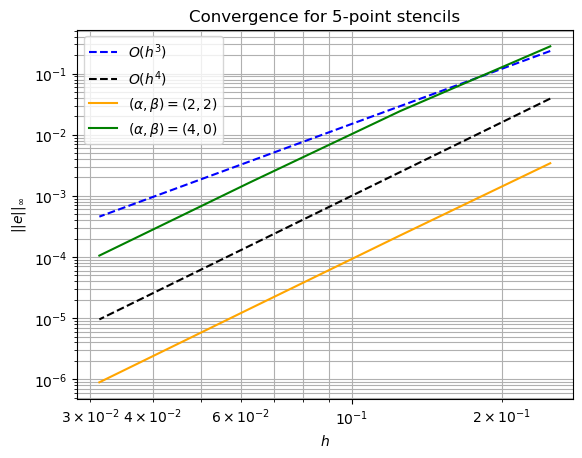

In [3]:
def fdcoeffV_uniform(k,xbar,stencil):
    n = len(stencil)
    A = np.ones((n,n))
    xrow = stencil
    for i in range(1,n):
        A[i,:]= xrow**(i)/math.factorial(i)

    b = np.zeros((n,))
    b[k] = 1
    c = np.linalg.solve(A,b)
    return 1/h**k * c

def sec_der(xbar,h,u_func,stencil):
    coeff = fdcoeffV_uniform(2,xbar,stencil)
    U = u_func(xbar+h*stencil)
    #print(U)
    der = np.dot(coeff,U)
    return der

def u_func(x):
    return np.exp(np.cos(x))


def fdcoeffV(k: int, xbar, x):
    '''
        # Parameters
        k: derivative order
        xbar: x[i]-value at which to approximate 
            k-th derivative stencil coefficients
        x: slice of x-points (x[i + stencil]) around xbar 
            to use in approximation

        # Output
        c: Coefficients of k-th order derivative of u at xbar
    '''
    n = len(x)
    A = np.ones((n,n))
    xrow = x - xbar
    for i in range(1,n):
        A[i,:]= xrow**(i)/scipy.special.factorial(i)

    b = np.zeros((n,))
    b[k] = 1
    c = np.linalg.solve(A,b)
    return c


#d2 = -np.cos(x)*np.exp(np.cos(x))+(np.sin(x))**2*np.exp(np.cos(x))
d2 = -np.exp(1)

hs = []
errs = []
xbar=0


errs2 = []

for i in range(2,6):
    
    h = 1/2**(i)
    err = abs(sec_der(xbar,h,u_func,np.array([-2,-1,0,1,2])) - d2)
    err2 = abs(sec_der(xbar,h,u_func,np.array([-4,-3,-2,-1,0])) - d2)

    hs.append(h)
    errs.append(err)
    errs2.append(err2)

hs = np.array(hs)
errs = np.array(errs)
errs2 = np.array(errs2)
#plt.rc('text', usetex=True)
#plt.rc('font', family='serif')


plt.loglog(hs,15*hs**3,"b--", label=r"$O(h^3)$")
plt.loglog(hs,10*hs**4, 'k--', label=r"$O(h^4)$")
plt.loglog(hs,errs,color="orange", label=r"$(\alpha, \beta) = (2,2)$")
plt.loglog(hs,errs2,color="g", label=r"$(\alpha, \beta) = (4,0)$")
plt.title("Convergence for 5-point stencils")
plt.xlabel(r'$h$')
plt.ylabel(r'$||e||_\infty$')
plt.grid(True, which = 'both')
plt.legend()
plt.show()

In [4]:
np.polyfit(np.log(hs),np.log(errs),1)

array([ 3.96956962, -0.16200765])

In [5]:
np.polyfit(np.log(hs[2:]),np.log(errs2[2:]),1)

array([3.96917988, 4.59935088])

# 1e)

In [7]:
hs = []
errs = []
errs2 = []
xbar=1
stencil = np.array([-3/2,-1/2, 1/2])

coeffs = fdcoeffV_uniform(0, xbar, stencil)

for i in range(2,6):
    h = 1/2**(i)
    U = u_func(xbar + stencil*h)
    u_zero = np.dot(coeffs,U)
    
    err = abs(u_zero - u_func(xbar))
    
    hs.append(h)
    errs.append(err)

hs = np.array(hs)
errs = np.array(errs)


stencil = np.array([-1/2, 1/2])

coeffs = fdcoeffV_uniform(0, xbar, stencil)
for i in range(2,6):
    h = 1/2**(i)
    U = u_func(xbar + stencil*h)
    u_zero = np.dot(coeffs,U)
    
    err = abs(u_zero - u_func(xbar))
    
    errs2.append(err)

errs2 = np.array(errs2)


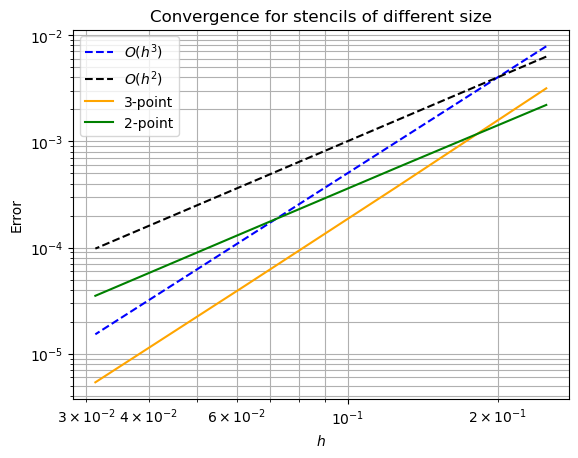

In [ ]:
plt.loglog(hs,1/2*hs**3,"b--", label=r"$O(h^3)$")
plt.loglog(hs,1/10*hs**2, 'k--', label=r"$O(h^2)$")
plt.loglog(hs,errs,color="orange", label="3-point")
plt.loglog(hs,errs2,color="g", label="2-point")
plt.title("Convergence for stencils of different size")
plt.xlabel(r'$h$')
plt.ylabel('Error')
plt.grid(True, which = 'both')
plt.legend()
plt.show()

In [9]:
np.polyfit(np.log(hs), np.log(errs), 1)

array([ 3.06221729, -1.52879684])

In [10]:
np.polyfit(np.log(hs), np.log(errs2), 1)

array([ 1.9886234 , -3.36021927])

# 1 g)

In [11]:
def fdcoeffV_uniform(k: int, h: float, stencil: np.ndarray):
    n = len(stencil)
    A = np.ones((n,n))
    for i in range(1,n):
        A[i,:]= stencil**(i)/factorial(i)

    b = np.zeros((n,))
    b[k] = 1
    c = np.linalg.solve(A,b)
    return 1/h**k * c

def der_approx_uniform(k: int, xbar: float, h, u_func, stencil):
    coeff = fdcoeffV_uniform(k,h,stencil)
    U = u_func(xbar+h*stencil)
    #print(U)
    der = np.dot(coeff,U)
    return der

In [12]:
from scipy.special import factorial


def RichardsonExtrapolation(k: int, xbar: float, h, u_func, stencil, p):
    Dh = der_approx_uniform(k, xbar, h, u_func, stencil)
    Dh2 = der_approx_uniform(k, xbar, h/2, u_func, stencil)

    return (2**p*Dh2 - Dh)/(2**p-1)





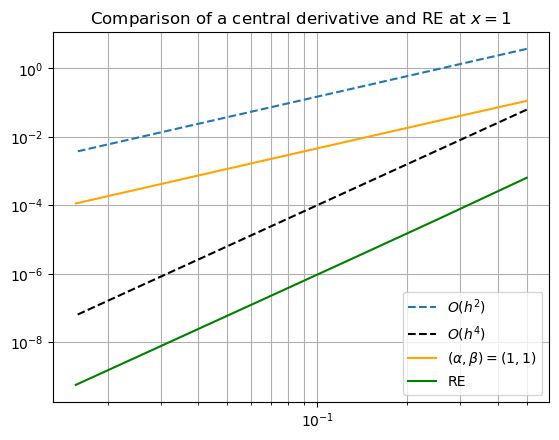

In [14]:


def u_func(x):
    return np.exp(np.cos(x))


# d1 = -np.sin(x)*np.exp(np.cos(x))
#d1 = 0 # x = 0
d1 = -np.sin(1)*np.exp(np.cos(1))
 

#d2 = -np.cos(x)*np.exp(np.cos(x))+(np.sin(x))**2*np.exp(np.cos(x))
d2 = -np.exp(1) # x = 0




hs = []
errs = []
xbar=1


errs2 = []

for i in range(1,7):
    
    h = 1/2**(i)
    #err = abs(sec_der(xbar,h,u_func,np.array([-2,-1,0,1,2])) - d2)
    #err2 = abs(sec_der(xbar,h,u_func,np.array([-4,-3,-2,-1,0])) - d2)
    err = abs(der_approx_uniform(1, xbar, h, u_func, np.array([-1,0,1])) - d1)
    err2 = abs(RichardsonExtrapolation(1, xbar, h, u_func, np.array([-1,0,1]),2) - d1)


    hs.append(h)
    errs.append(err)
    errs2.append(err2)

hs = np.array(hs)
errs = np.array(errs)
errs2 = np.array(errs2)
#plt.rc('text', usetex=True)
#plt.rc('font', family='serif')


plt.loglog(hs,15*hs**2,"--", label=r"$O(h^2)$")
#plt.loglog(hs,15*hs**3,"b--", label=r"$O(h^3)$")
plt.loglog(hs,1*hs**4, 'k--', label=r"$O(h^4)$")
#plt.loglog(hs,1/25*hs**5, 'b--', label=r"$O(h^5)$")
#plt.loglog(hs,1/3*hs**6, 'r--', label=r"$O(h^6)$")

plt.loglog(hs,errs,color="orange", label=r"$(\alpha, \beta) = (1,1)$")
plt.loglog(hs,errs2,color="g", label=r"RE")
plt.title("Comparison of a central derivative and RE at $x=1$")
plt.grid(True, which = 'both')
plt.legend()
plt.show()

In [15]:
np.polyfit(np.log(hs[2:]), np.log(errs[2:]), 1)

array([ 1.99942705, -0.77768183])

In [16]:
np.polyfit(np.log(hs[4:]), np.log(errs2[4:]), 1)

array([ 4.00045363, -4.67971148])

In [17]:
def fdcoeffV_uniform(k: int, h: float, stencil: np.ndarray):
    n = len(stencil)
    A = np.ones((n,n))
    for i in range(1,n):
        A[i,:]= stencil**(i)/factorial(i)

    b = np.zeros((n,))
    b[k] = 1
    c = np.linalg.solve(A,b)
    return 1/h**k * c

def der_approx_uniform(k: int, xbar: float, h, u_func, stencil):
    coeff = fdcoeffV_uniform(k,h,stencil)
    U = u_func(xbar+h*stencil)
    #print(U)
    der = np.dot(coeff,U)
    return der

In [18]:
def RichardsonExtrapolation(k: int, xbar: float, h, u_func, stencil, p):
    Dh = der_approx_uniform(k, xbar, h, u_func, stencil)
    Dh2 = der_approx_uniform(k, xbar, h/2, u_func, stencil)
    return (2**p*Dh2 - Dh)/(2**p-1)

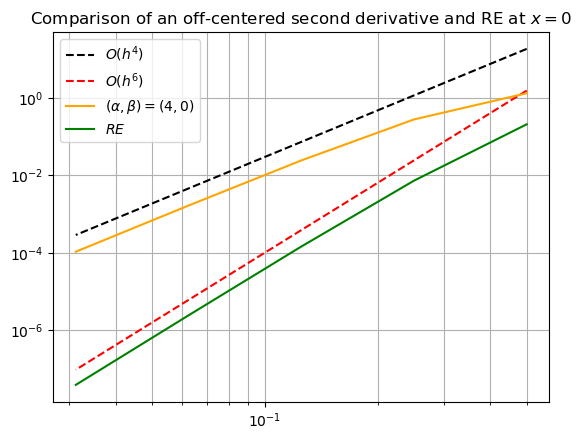

In [19]:
def fdcoeffV_uniform(k: int, h: float, stencil: np.ndarray):
    n = len(stencil)
    A = np.ones((n,n))
    for i in range(1,n):
        A[i,:]= stencil**(i)/factorial(i)

    b = np.zeros((n,))
    b[k] = 1
    c = np.linalg.solve(A,b)
    return 1/h**k * c

def der_approx_uniform(k: int, xbar: float, h, u_func, stencil):
    coeff = fdcoeffV_uniform(k,h,stencil)
    U = u_func(xbar+h*stencil)
    #print(U)
    der = np.dot(coeff,U)
    return der

def sec_der(xbar,h,u_func,stencil):
    coeff = fdcoeffV_uniform(2,h,stencil)
    U = u_func(xbar+h*stencil)
    #print(U)
    der = np.dot(coeff,U)
    return der


def RichardsonExtrapolation(k: int, xbar: float, h, u_func, stencil, p):
    Dh = der_approx_uniform(k, xbar, h, u_func, stencil)
    Dh2 = der_approx_uniform(k, xbar, h/2, u_func, stencil)

    return (2**p*Dh2 - Dh)/(2**p-1)




def u_func(x):
    return np.exp(np.cos(x))

 

 
#d2 = -np.cos(x)*np.exp(np.cos(x))+(np.sin(x))**2*np.exp(np.cos(x))
d2 = -np.exp(1) # x = 0


hs = []
errs = []
xbar=0


errs2 = []

for i in range(1,6):
    
    h = 1/2**(i)
    #err = abs(sec_der(xbar,h,u_func,np.array([-2,-1,0,1,2])) - d2)
    #err = abs(sec_der(xbar,h,u_func,np.array([-4,-3,-2,-1,0])) - d2)
    #err = abs(der_approx_uniform(2, xbar, h, u_func, np.array([-2,-1,0,1,2])) - d2)
    err = abs(der_approx_uniform(2, xbar, h, u_func, np.array([-4,-3,-2,-1,0])) - d2)
    #err = abs(sec_der(xbar,h,u_func,np.array([-4,-3,-2,-1,0])) - d2)
    err2 = abs(RichardsonExtrapolation(2, xbar, h, u_func, np.array([-4,-3,-2,-1,0]),4)-d2)
    #err2 = abs(RichardsonExtrapolation(2, xbar, h, u_func, np.array([-2,-1,0,1,2]),4) - d2)

    hs.append(h)
    errs.append(err)
    errs2.append(err2)

hs = np.array(hs)
errs = np.array(errs)
errs2 = np.array(errs2)
#plt.rc('text', usetex=True)
#plt.rc('font', family='serif')


#plt.loglog(hs,15*hs**3,"b--", label=r"$O(h^3)$")
plt.loglog(hs,300*hs**4, 'k--', label=r"$O(h^4)$")
plt.loglog(hs,100*hs**6, 'r--', label=r"$O(h^6)$")

plt.loglog(hs,errs,color="orange", label=r"$(\alpha, \beta) = (4,0)$")
plt.loglog(hs,errs2,color="g", label=r"$RE$")
plt.title("Comparison of an off-centered second derivative and RE at $x=0$")
plt.grid(True, which = 'both')
plt.legend()
plt.show()

In [20]:
np.polyfit(np.log(hs[3:]), np.log(errs[3:]), 1)

array([3.96917988, 4.59935088])

In [22]:
np.polyfit(np.log(hs[3:]), np.log(errs2[3:]), 1)

array([5.97771857, 3.62475229])